# Fig S9 - inverse-inference true-perturbation gene ranking

Reproduces Fig S9: how well the inverse model recovers the *true* perturbed gene, scored by absolute rank of the true target across candidate genes, compared against the `|LFC|` baseline (and, where enabled, mean-field / true-covariance scores).

**Pipeline.** The first cell reloads the saved per-perturbation rank arrays (`perpert_metrics.npz`) produced by a prior *inverse-fast* run, one directory per dataset, and compiles per-dataset / pooled / dataset-balanced rank summaries. The three plotting cells are successive figure variants (paired-line dots; best/worst-labelled with dataset-mean diamonds; best/worst-labelled with pooled-perturbation diamonds); each writes the same figure/CSV stems, so the last cell produces the canonical panel.

Helpers live in `notebooks/src/suppl_generanking.py`. The two plotting functions that are redefined incompatibly across the three variants (`add_summary_marker`, `plot_metric_panel`) are kept inline in each cell so every variant reproduces exactly.

**Data.** Prior inverse-run outputs under `$CIPHER_DATA_DIR/suppl/posterior_inverse_fast_from_prerun_fullH_diag/mean_ge_1p0/run_*/` (one `perpert_metrics.npz` per dataset plus `ALL_DATASETS_inverse_summary.csv`). *Verification pending: that run directory is not yet staged under SUPPL.*

In [1]:
import os, sys
# route tqdm progress bars to text (stderr -> log) instead of un-renderable ipywidgets
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm', 'tqdm.auto', 'tqdm.notebook', 'tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception:
    pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "suppl" else os.getcwd())

# notebook-only helpers (in notebooks/src; not part of the cipher package)
from src.suppl_generanking import *
DATA_DIR = os.environ["CIPHER_DATA_DIR"]   # set in the sbatch script; no fallback
SUPPL = os.path.join(DATA_DIR, "suppl")
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/figS9")
os.makedirs(OUTDIR, exist_ok=True)
from src.logutil import route_logs  # verbose logs -> .log, plots stay in-cell
route_logs("figS9_generanking")
print("data dir:", DATA_DIR)
print("suppl:", SUPPL)
print("outdir:", OUTDIR)

[logs] verbose output -> ../../resources/repro/figS9/logs/figS9_generanking.log
data dir: $CIPHER_DATA_DIR
suppl: $SUPPL
outdir: $SUPPL_OUT


In [2]:
import src.run_figS9 as R
import src.suppl_generanking as C
_cfg = {k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR", "SUPPL", "OUTDIR")}
R.__dict__.update(_cfg)
C.__dict__.update(_cfg)

## 1. Load saved true-target ranks and compile summaries

In [3]:
R.load_and_summarize()

## 2. Figure variant A - dataset dots with paired lines

Mean / median rank and top-1 fraction; one dot per dataset, violins across datasets, faint lines linking the same dataset across methods.

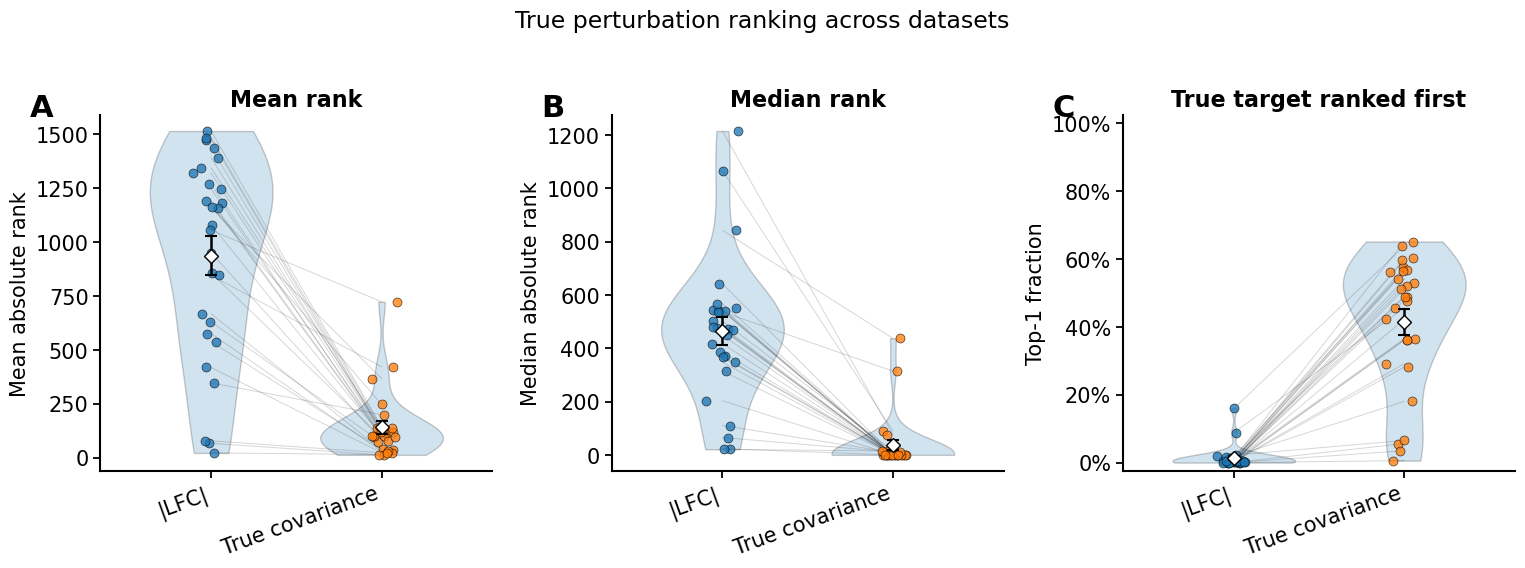

In [4]:
R.figure_variant_a()

## 3. Figure variant B - best/worst labels, dataset-mean diamonds

As variant A but labels the best/worst datasets and marks the unweighted mean-across-datasets (white diamond, mean +/- SEM).

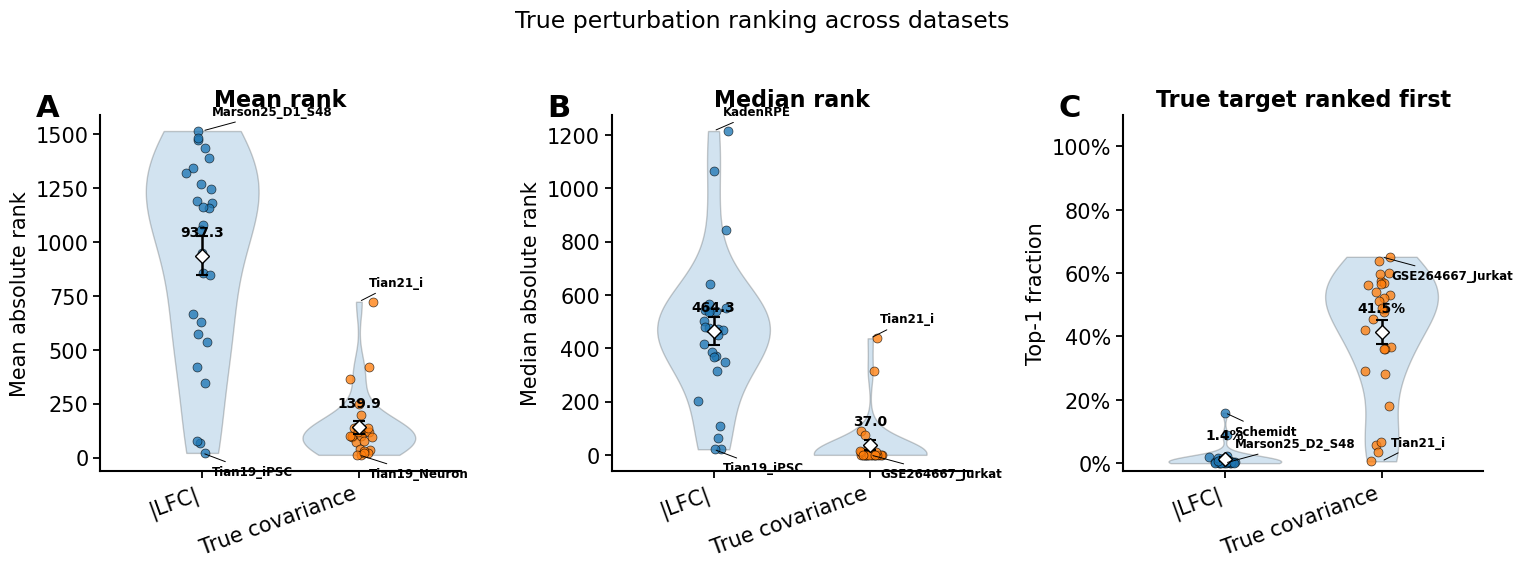

In [5]:
R.figure_variant_b()

## 4. Figure variant C - best/worst labels, pooled-perturbation diamonds (canonical)

As variant B but the white diamond summarizes all perturbations pooled across datasets rather than an average of dataset-level values.

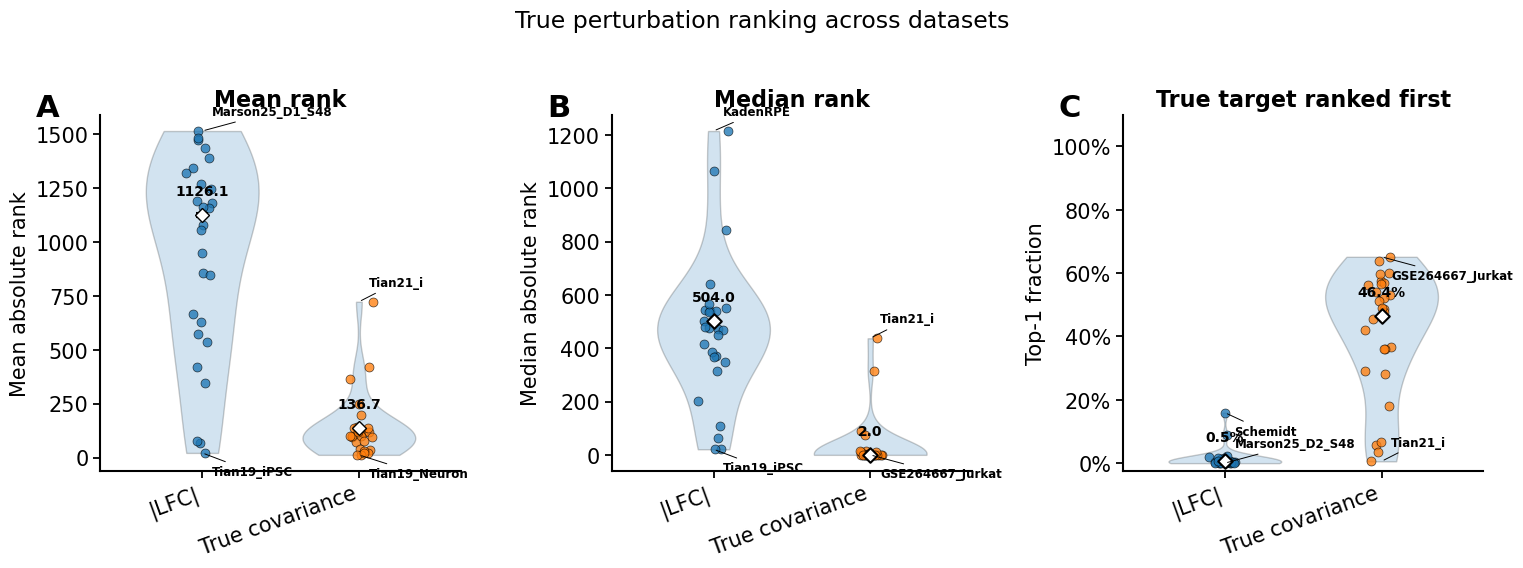

In [6]:
R.figure_variant_c()